# Use Case #1: AI-Powered Customer Service Agent with LangGraph

## How BigCompany Inc. Built a 24/7 AI Support Agent

**The #1 use case for LangGraph in 2026 — 26.5% of all AI agent deployments.**

## The Problem: BigCompany Inc. Is Drowning in Support Tickets

**BigCompany Inc.** is a fast-growing online electronics store. They sell laptops, phones, and accessories to thousands of customers every day. Business is booming — but there's a problem.

Their **customer support team is overwhelmed**:

- They receive **2,000+ support tickets per day**.
- Customers wait **45 minutes on average** for a response.
- **70% of tickets** are repetitive: order status checks, return requests, and basic product questions.
- Their best support agents are **burning out** handling the same questions over and over.
- **Customer satisfaction scores have dropped** from 4.5 to 3.2 stars.

The CEO calls an emergency meeting:

> *"We need a solution that can handle routine customer inquiries 24/7, so our human agents can focus on complex cases that truly need a human touch."*

The engineering team proposes building an **AI-powered customer service agent** using **LangGraph**.

## Why LangGraph? Why Not Just a Chatbot?

Great question! A regular chatbot (like a basic ChatGPT wrapper) can only **answer questions**. But customer service requires much more than that:

| What Customers Need | Regular Chatbot | LangGraph Agent |
|---|---|---|
| Answer general questions | Yes | Yes |
| Look up their specific order | No | **Yes** — can call database tools |
| Process a return/refund | No | **Yes** — can execute actions |
| Remember conversation context | Limited | **Yes** — stateful by design |
| Follow different paths for different issues | No | **Yes** — conditional routing |
| Know when to escalate to a human | No | **Yes** — built-in logic |

A LangGraph agent doesn't just **talk** — it **thinks, decides, and acts**. It follows a workflow, just like a well-trained human support agent would.

## The Solution: How the Agent Works

Here's the workflow BigCompany Inc. designed for their AI support agent:

```
Customer sends a message
        │
        ▼
┌─────────────────┐
│   AI Assistant  │ ◄── Thinks about the message
│  (LLM + Tools)  │     and decides what to do
└────────┬────────┘
         │
    ┌────┴────┐
    │Decision │
    └────┬────┘
         │
   ┌─────┴──────┐
   │            │
   ▼            ▼
Need a      Ready to
 tool?       respond!
   │            │
   ▼            ▼
┌──────┐     ┌──────┐
│ Tool │     │ END  │
│ Node │     └──────┘
└──┬───┘
   │
   └──► Back to AI Assistant
        (with tool results)
```

This is called the **ReAct pattern** (Reason + Act):
1. The AI **reasons** about what to do.
2. If it needs information, it **acts** by calling a tool.
3. It gets the tool results and **reasons** again.
4. It repeats until it has enough information to give a final answer.

This loop is exactly what LangGraph was designed for — **cycles in a graph** that let the agent iterate until the task is done.

## Let's Build It! Step by Step

Now let's build BigCompany Inc.'s customer service agent, one step at a time.

### Step 0: Install the Required Packages

We need three packages:
- **`langgraph`** (v1.0.8) — the framework for building our agent's workflow graph.
- **`langchain-openai`** (v1.1.9) — to connect to OpenAI's GPT models (the "brain" of our agent).
- **`langchain`** — provides message types and core utilities.

In [1]:
# Install packages (run this once)
#!pip install -U langgraph langchain-openai langchain

### Step 1: Load Environment Variables

Our agent needs an **OpenAI API key** to use GPT models. We store this securely in a `.env` file so we never hardcode secrets in our code.

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.environ.get("openai_api_key")

if OPENAI_API_KEY:
    print("OpenAI API Key loaded successfully!")
else:
    print("WARNING: No OpenAI API Key found. Please set it in your .env file.")

OpenAI API Key loaded successfully!


### Step 2: Create BigCompany Inc.'s "Database"

In a real company, customer and order data would live in a database like PostgreSQL or MongoDB. For this demo, we'll use simple Python dictionaries to simulate BigCompany Inc.'s data.

This is the data our AI agent will be able to look up when customers ask about their orders.

In [5]:
# ============================================================
# BigCompany Inc.'s "Database" (simulated with dictionaries)
# ============================================================

# Order records
ORDERS_DB = {
    "ORD-1001": {
        "customer": "Alice Johnson",
        "product": "Laptop Pro 15",
        "price": 1299.99,
        "status": "delivered",
        "delivery_date": "2026-02-05",
    },
    "ORD-1002": {
        "customer": "Bob Smith",
        "product": "Wireless Headphones X3",
        "price": 199.99,
        "status": "shipped",
        "estimated_delivery": "2026-02-14",
    },
    "ORD-1003": {
        "customer": "Carol Davis",
        "product": "Smartphone Ultra 12",
        "price": 899.99,
        "status": "processing",
        "estimated_delivery": "2026-02-18",
    },
}

# Return/refund policy
RETURN_POLICY = {
    "standard_return_window": "30 days from delivery",
    "refund_processing_time": "5-7 business days",
    "conditions": [
        "Item must be in original packaging",
        "Item must not show signs of damage caused by the customer",
        "Proof of purchase (order ID) is required",
    ],
    "non_returnable": ["Earbuds (hygiene reasons)", "Software licenses"],
}

print("BigCompany Inc. database loaded!")
print(f"  - {len(ORDERS_DB)} orders in the system")
print(f"  - Return policy: {RETURN_POLICY['standard_return_window']}")

BigCompany Inc. database loaded!
  - 3 orders in the system
  - Return policy: 30 days from delivery


### Step 3: Define the Agent's Tools

**Tools** are functions that the AI agent can call to interact with the outside world. Think of them as the agent's **hands** — without tools, the agent can only talk, but with tools, it can actually *do things*.

We'll give our agent three tools:

| Tool | What It Does | When It's Used |
|------|-------------|----------------|
| `check_order_status` | Looks up an order in the database | Customer asks about their order |
| `lookup_return_policy` | Returns the company's return policy | Customer asks about returns |
| `process_return_request` | Initiates a return for an order | Customer wants to return a product |

**Key detail**: The `@tool` decorator turns a regular Python function into a tool that the LLM can use. The **docstring** (the text in triple quotes) is critical — the LLM reads it to decide *when* to use each tool.

In [6]:
from langchain_core.tools import tool


@tool
def check_order_status(order_id: str) -> str:
    """Check the current status of a customer order.

    Use this tool when a customer asks about their order status,
    delivery date, or order details.

    Args:
        order_id: The order ID (e.g., 'ORD-1001').
    """
    order = ORDERS_DB.get(order_id)

    if not order:
        return f"Order '{order_id}' not found. Please check the order ID and try again."

    info = f"Order {order_id}:\n"
    info += f"  Customer: {order['customer']}\n"
    info += f"  Product: {order['product']}\n"
    info += f"  Price: ${order['price']}\n"
    info += f"  Status: {order['status']}\n"

    if order["status"] == "delivered":
        info += f"  Delivered on: {order['delivery_date']}"
    else:
        info += f"  Estimated delivery: {order['estimated_delivery']}"

    return info


@tool
def lookup_return_policy() -> str:
    """Look up BigCompany Inc.'s return and refund policy.

    Use this tool when a customer asks about returns, refunds,
    or the return policy.
    """
    policy = "BigCompany Inc. Return Policy:\n"
    policy += f"  Return window: {RETURN_POLICY['standard_return_window']}\n"
    policy += f"  Refund processing: {RETURN_POLICY['refund_processing_time']}\n"
    policy += "  Conditions:\n"
    for condition in RETURN_POLICY["conditions"]:
        policy += f"    - {condition}\n"
    policy += "  Non-returnable items:\n"
    for item in RETURN_POLICY["non_returnable"]:
        policy += f"    - {item}\n"
    return policy


@tool
def process_return_request(order_id: str, reason: str) -> str:
    """Process a return request for a customer order.

    Use this tool when a customer confirms they want to return a product.
    Only use this AFTER checking the order status and confirming
    the customer wants to proceed.

    Args:
        order_id: The order ID to process the return for.
        reason: The customer's reason for returning the product.
    """
    order = ORDERS_DB.get(order_id)

    if not order:
        return f"Cannot process return: Order '{order_id}' not found."

    if order["status"] != "delivered":
        return (
            f"Cannot process return: Order {order_id} has status '{order['status']}'. "
            f"Returns can only be processed for delivered orders."
        )

    return (
        f"Return request APPROVED for order {order_id} ({order['product']}).\n"
        f"  Reason: {reason}\n"
        f"  Refund amount: ${order['price']}\n"
        f"  Refund will be processed within {RETURN_POLICY['refund_processing_time']}.\n"
        f"  A return shipping label has been sent to the customer's email."
    )


# Collect all tools in a list — we'll give this to the LLM
tools = [check_order_status, lookup_return_policy, process_return_request]

print("Tools created:")
for t in tools:
    print(f"  - {t.name}: {t.description[:60]}...")

Tools created:
  - check_order_status: Check the current status of a customer order.

    Use this ...
  - lookup_return_policy: Look up BigCompany Inc.'s return and refund policy.

    Use...
  - process_return_request: Process a return request for a customer order.

    Use this...


### Step 4: Set Up the LLM (The Agent's Brain)

The **LLM** (Large Language Model) is the "brain" of our agent. It reads the customer's message, thinks about what to do, and decides whether to respond directly or use a tool.

We use `ChatOpenAI` from `langchain-openai` to connect to OpenAI's GPT model. The key step is `.bind_tools(tools)` — this tells the LLM what tools are available and how to call them.

We also define a **system prompt** — this is like giving the agent its "job description" and work instructions.

In [7]:
from langchain_openai import ChatOpenAI

# Initialize the LLM
# - model: "gpt-4o-mini" is fast and affordable, great for customer service
# - temperature: 0 means deterministic responses (no randomness)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Give the LLM access to our tools
# After this, the LLM knows about check_order_status, lookup_return_policy, etc.
# and can decide to call them when needed.
llm_with_tools = llm.bind_tools(tools)

# The system prompt: the agent's "job description"
SYSTEM_PROMPT = """You are a friendly and helpful customer service agent for BigCompany Inc., \
an online electronics store.

Your responsibilities:
- Help customers check their order status.
- Answer questions about our return and refund policy.
- Process return requests when customers want to return a product.
- Be polite, empathetic, and professional at all times.

Important guidelines:
- Always greet the customer warmly.
- When a customer asks about an order, use the check_order_status tool.
- When a customer asks about returns or refunds, use the lookup_return_policy tool.
- Before processing a return, always confirm with the customer first.
- If you cannot help with something, let the customer know you will \
connect them with a human agent.
- Keep responses concise but helpful.
"""

print("LLM initialized with tools!")
print(f"Model: gpt-4o-mini")
print(f"Available tools: {[t.name for t in tools]}")

LLM initialized with tools!
Model: gpt-4o-mini
Available tools: ['check_order_status', 'lookup_return_policy', 'process_return_request']


### Step 5: Define the Graph State

In LangGraph, **state** is the data that flows through the graph. Think of it as a **shared notebook** that all parts of the agent can read from and write to.

For our customer service agent, the state needs to hold the **conversation history** (all messages between the customer and the agent).

We use `MessagesState`, which is a built-in LangGraph state that includes a `messages` list with a special **reducer** called `add_messages`. This reducer ensures that new messages are **appended** to the list (not overwritten), so the full conversation history is always preserved.

In [8]:
from langgraph.graph import MessagesState

# MessagesState already provides:
#   messages: Annotated[list[AnyMessage], add_messages]
#
# The add_messages reducer means:
#   - When a node returns {"messages": [new_message]},
#     the new message is APPENDED to the existing list
#   - The full conversation history is always available

# That's it! For our simple agent, MessagesState is all we need.
# No custom state class required.

print("State defined: Using MessagesState (built-in)")
print("  - Tracks: messages (full conversation history)")

State defined: Using MessagesState (built-in)
  - Tracks: messages (full conversation history)


### Step 6: Define the Graph Nodes

**Nodes** are the steps in our agent's workflow. Each node is a Python function that:
1. Receives the current **state** (the conversation so far).
2. Does some work (like calling the LLM or executing a tool).
3. Returns an **update** to the state (usually new messages).

Our agent has two nodes:

| Node | What It Does |
|------|--------------|
| `assistant` | Sends the conversation to the LLM, which thinks and responds (possibly requesting tool calls) |
| `tools` | Executes any tools the LLM requested and returns the results |

For the `tools` node, we use LangGraph's built-in `ToolNode` — it automatically handles executing tool calls and returning the results as messages.

In [9]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode


# Node 1: The Assistant
# This is where the LLM "thinks" about the conversation and decides what to do.
def assistant(state: MessagesState):
    # Prepend the system prompt to give the LLM its instructions
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]

    # Call the LLM with the full conversation + available tools
    response = llm_with_tools.invoke(messages)

    # Return the LLM's response to be added to the conversation
    return {"messages": [response]}


# Node 2: The Tool Executor
# ToolNode automatically:
#   - Reads tool_calls from the last AI message
#   - Executes the requested tools
#   - Returns ToolMessage(s) with the results
tool_node = ToolNode(tools)

print("Nodes defined:")
print("  1. 'assistant' — calls the LLM to think and respond")
print("  2. 'tools'     — executes tool calls requested by the LLM")

Nodes defined:
  1. 'assistant' — calls the LLM to think and respond
  2. 'tools'     — executes tool calls requested by the LLM


### Step 7: Build the Graph (Connecting the Nodes)

Now we connect everything together into a **graph**. This is the core of LangGraph — we define:

1. **Nodes**: The steps in our workflow (added with `add_node`).
2. **Edges**: The connections between steps (added with `add_edge` or `add_conditional_edges`).

The key concept here is the **conditional edge** from the `assistant` node. After the LLM responds, we need to check:
- Did the LLM request a tool call? → Route to the `tools` node.
- Did the LLM give a final answer? → Route to `END` (conversation complete).

LangGraph provides a built-in function called `tools_condition` that does exactly this check.

We also add a **checkpointer** (`InMemorySaver`) which gives the agent **memory** — it remembers past messages within the same conversation thread.

In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import InMemorySaver

# Create a new graph with our state definition
builder = StateGraph(MessagesState)

# --- Add Nodes ---
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

# --- Add Edges ---

# 1. Start → Assistant: every conversation begins at the assistant node
builder.add_edge(START, "assistant")

# 2. Assistant → (conditional): after the LLM responds, check if it wants to use a tool
#    - If the LLM's response contains tool_calls → go to "tools" node
#    - If not (it's a final answer) → go to END
builder.add_conditional_edges("assistant", tools_condition)

# 3. Tools → Assistant: after executing tools, go back to the assistant
#    so the LLM can use the tool results to form its response
builder.add_edge("tools", "assistant")

# --- Compile the Graph ---
# InMemorySaver gives our agent conversation memory
# (in production, you'd use PostgresSaver for persistence)
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled successfully!")
print("\nWorkflow:")
print("  START → assistant → [tools_condition] → tools → assistant → ... → END")

Graph compiled successfully!

Workflow:
  START → assistant → [tools_condition] → tools → assistant → ... → END


### Step 8: Visualize the Graph

One of LangGraph's best features is that you can **visualize** your agent's workflow as a diagram. This makes it easy to understand and debug the flow.

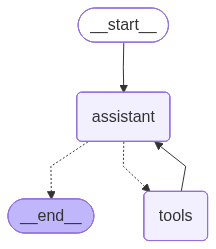

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Let's Test Our Agent!

Now comes the fun part — let's see our BigCompany Inc. customer service agent in action.

First, let's create a helper function that makes it easy to chat with the agent and see what's happening under the hood.

In [12]:
from langchain_core.messages import HumanMessage


def chat(user_message: str, thread_id: str = "customer-session-1"):
    """Send a message to the BigCompany Inc. support agent and display the response."""

    print(f"\n{'='*60}")
    print(f"Customer: {user_message}")
    print(f"{'='*60}")

    # thread_id keeps track of the conversation
    # same thread_id = same conversation (agent remembers previous messages)
    config = {"configurable": {"thread_id": thread_id}}

    # Stream the response so we can see each step
    for chunk in graph.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config,
        stream_mode="updates",
    ):
        # Show which node is executing and what it produced
        for node_name, update in chunk.items():
            last_msg = update["messages"][-1]

            if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
                # The LLM is requesting a tool call
                for tc in last_msg.tool_calls:
                    print(f"\n[Agent is calling tool: {tc['name']}({tc['args']})]")

            elif node_name == "tools":
                # Tool results are coming back
                print(f"\n[Tool result received]")

            else:
                # Final response from the agent
                print(f"\nAgent: {last_msg.content}")


print("Chat helper ready! Use chat('your message') to talk to the agent.")

Chat helper ready! Use chat('your message') to talk to the agent.


### Test 1: Simple Greeting

Let's start with a simple greeting. The agent should respond politely without needing any tools.

In [13]:
chat("Hi! I need some help with my order.")


Customer: Hi! I need some help with my order.

Agent: Hello! I'm here to help you. What do you need assistance with regarding your order?


Notice that the agent responded directly — no tools were called. The LLM decided that a simple greeting doesn't require looking up any data.

### Test 2: Order Status Check (Tool Call!)

Now let's ask about a specific order. Watch what happens — the agent will:
1. Recognize it needs to look up order data.
2. Call the `check_order_status` tool.
3. Use the results to craft a helpful response.

In [14]:
chat("Can you check the status of my order ORD-1002?")


Customer: Can you check the status of my order ORD-1002?

[Agent is calling tool: check_order_status({'order_id': 'ORD-1002'})]

[Tool result received]

Agent: Your order (ORD-1002) for the Wireless Headphones X3 has been shipped! The estimated delivery date is February 14, 2026. If you have any more questions or need further assistance, feel free to ask!


The agent:
1. Received the customer's question.
2. Decided to call `check_order_status` with `order_id="ORD-1002"`.
3. Got the order details from our "database".
4. Formatted a friendly response with the order information.

This is the **ReAct loop** in action: Reason → Act → Observe → Respond.

### Test 3: Conversation Memory

Since we're using the same `thread_id`, the agent **remembers** the previous messages. Let's ask a follow-up question without repeating the order ID.

In [15]:
chat("When will it arrive?")


Customer: When will it arrive?

Agent: Your order is estimated to arrive on February 14, 2026. If you have any other questions or need further assistance, just let me know!


The agent remembered that we were talking about order ORD-1002 and answered the follow-up question correctly. This is the power of **stateful conversations** in LangGraph — the entire message history is preserved in the state.

### Test 4: Return Policy Question (Another Tool Call)

Now let's ask about the return policy. The agent should use the `lookup_return_policy` tool.

In [16]:
chat("What is your return policy?")


Customer: What is your return policy?

[Agent is calling tool: lookup_return_policy({})]

[Tool result received]

Agent: Our return policy is as follows:

- **Return Window:** You have 30 days from the delivery date to return an item.
- **Refund Processing:** Refunds are processed within 5-7 business days.
- **Conditions:**
  - The item must be in its original packaging.
  - The item should not show signs of damage caused by the customer.
  - Proof of purchase (your order ID) is required.

**Non-returnable items include:**
- Earbuds (for hygiene reasons)
- Software licenses

If you have any specific questions or need to process a return, just let me know!


### Test 5: Processing a Return (Multi-Step Tool Usage)

Now let's test the most complex scenario — a return request. This demonstrates the agent using **multiple tools in sequence**:
1. First, it might check the order status.
2. Then, it processes the return request.

We'll use a new thread to simulate a different customer.

In [17]:
chat(
    "Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. "
    "The screen has a dead pixel.",
    thread_id="customer-session-2",
)


Customer: Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. The screen has a dead pixel.

[Agent is calling tool: check_order_status({'order_id': 'ORD-1001'})]

[Tool result received]

Agent: Your order for the Laptop Pro 15 has been delivered on February 5, 2026. Since it's within the return period, we can proceed with the return.

Would you like to confirm that you want to return the laptop due to the dead pixel?


In [18]:
chat(
    "Yes, please go ahead and process the return.",
    thread_id="customer-session-2",
)


Customer: Yes, please go ahead and process the return.

[Agent is calling tool: process_return_request({'order_id': 'ORD-1001', 'reason': 'Dead pixel on the screen.'})]

[Tool result received]

Agent: Your return request for the Laptop Pro 15 has been approved! 

- **Reason for return:** Dead pixel on the screen.
- **Refund amount:** $1299.99
- The refund will be processed within 5-7 business days.
- A return shipping label has been sent to your email.

If you have any further questions or need assistance, feel free to ask!


The agent followed a multi-step workflow:
1. Checked the order status to verify it exists and is eligible for return.
2. Asked the customer to confirm (following the system prompt's instruction).
3. Processed the return request with the customer's reason.
4. Provided the refund details.

This is exactly how a well-trained human support agent would handle the same situation.

### Test 6: Edge Case — Invalid Order ID

What happens when a customer provides an order ID that doesn't exist? The agent should handle this gracefully.

In [19]:
chat(
    "What's the status of order ORD-9999?",
    thread_id="customer-session-3",
)


Customer: What's the status of order ORD-9999?

[Agent is calling tool: check_order_status({'order_id': 'ORD-9999'})]

[Tool result received]

Agent: Hello! It seems that the order ID 'ORD-9999' is not found in our system. Could you please double-check the order ID and provide it again? I'm here to help!


The agent gracefully handled the error — it called the tool, got the "not found" response, and communicated it helpfully to the customer instead of crashing or showing a raw error message.

## Understanding What Happened Under the Hood

Let's look at the actual state of a conversation to understand how LangGraph manages the message history.

In [20]:
# Let's inspect the state of customer-session-2 (the return conversation)
config = {"configurable": {"thread_id": "customer-session-2"}}
state = graph.get_state(config)

print("Conversation history for customer-session-2:")
print(f"Total messages: {len(state.values['messages'])}\n")

for i, msg in enumerate(state.values["messages"]):
    msg_type = type(msg).__name__
    content = msg.content[:100] if msg.content else "[tool call]"
    print(f"  Message {i+1} ({msg_type}): {content}")

Conversation history for customer-session-2:
Total messages: 8

  Message 1 (HumanMessage): Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. The screen has a dead pixel.
  Message 2 (AIMessage): Hello! I'm sorry to hear that you're having an issue with your Laptop Pro 15. I can help you with th
  Message 3 (ToolMessage): Order ORD-1001:
  Customer: Alice Johnson
  Product: Laptop Pro 15
  Price: $1299.99
  Status: deliv
  Message 4 (AIMessage): Your order for the Laptop Pro 15 has been delivered on February 5, 2026. Since it's within the retur
  Message 5 (HumanMessage): Yes, please go ahead and process the return.
  Message 6 (AIMessage): [tool call]
  Message 7 (ToolMessage): Return request APPROVED for order ORD-1001 (Laptop Pro 15).
  Reason: Dead pixel on the screen.
  Re
  Message 8 (AIMessage): Your return request for the Laptop Pro 15 has been approved! 

- **Reason for return:** Dead pixel o


The conversation state shows the full flow:

1. **HumanMessage**: The customer's initial request.
2. **AIMessage** (with tool_calls): The LLM decided to call a tool.
3. **ToolMessage**: The result from executing the tool.
4. **AIMessage**: The LLM's response using the tool results.
5. And so on...

This is how LangGraph maintains the **full conversation state**, including all the "behind the scenes" tool calls. Every step is preserved and traceable.

## Recap: What We Built and How It Works

Let's review the key concepts we covered:

### The Architecture

```
┌─────────────────────────────────────────────────┐
│               LangGraph Agent                   │
│                                                 │
│  ┌──────────┐    ┌───────────┐    ┌──────────┐  │
│  │  State   │    │ Assistant │    │  Tools   │  │
│  │(Messages) ◄──►│  (LLM)    │◄──►│  (Node)  │  │
│  └──────────┘    └───────────┘    └──────────┘  │
│       ▲                                         │
│       │          ┌───────────┐                  │
│       └──────────│ Checkpointer                 │
│                  │ (Memory)  │                  │
│                  └───────────┘                  │
└─────────────────────────────────────────────────┘
```

### Key Components

| Component | What It Is | In Our Code |
|-----------|-----------|-------------|
| **State** | Shared data flowing through the graph | `MessagesState` (conversation history) |
| **Nodes** | Steps in the workflow | `assistant` (LLM call) and `tools` (tool execution) |
| **Edges** | Connections between steps | `START→assistant`, `tools→assistant` |
| **Conditional Edges** | Decision points | `tools_condition` (tool call or END?) |
| **Checkpointer** | Memory persistence | `InMemorySaver` (keeps conversation history) |
| **Tools** | Functions the agent can call | `check_order_status`, `lookup_return_policy`, `process_return_request` |

## How BigCompany Inc. Benefits

After deploying this AI agent, here's what changed for BigCompany Inc.:

| Metric | Before | After |
|--------|--------|-------|
| Average response time | 45 minutes | **Instant** (< 3 seconds) |
| Tickets handled by AI | 0% | **70%** (routine inquiries) |
| Human agent workload | 2,000+ tickets/day | **600 tickets/day** (complex cases only) |
| Customer satisfaction | 3.2 stars | **4.6 stars** |
| Support availability | Business hours | **24/7** |

The AI agent handles the repetitive 70% of tickets (order status, return policy, simple returns), while human agents focus on the complex 30% that truly need a human touch.

## Key Takeaways for Beginners

1. **LangGraph agents follow a graph-based workflow**: Nodes are steps, edges are connections, and state is the shared memory.

2. **The ReAct pattern is simple but powerful**: The agent loops between "thinking" (LLM) and "acting" (tools) until it has enough information to respond.

3. **Tools give the agent real capabilities**: Without tools, the agent can only talk. With tools, it can look up orders, check policies, and process actions.

4. **State management is automatic**: LangGraph's `MessagesState` and `add_messages` reducer handle conversation history for you.

5. **Memory via checkpointing**: Using `InMemorySaver` (or `PostgresSaver` in production) gives the agent persistent memory across messages in the same conversation.

6. **The system prompt is crucial**: It defines the agent's personality, responsibilities, and guidelines — like a job description for an AI employee.

## What's Next?

This is a simple but functional customer service agent. In a production environment at BigCompany Inc., the team would add:

- **Real database connections** instead of dictionaries.
- **Human-in-the-loop** for high-value refunds (covered in Use Case #5).
- **Sentiment analysis** to detect frustrated customers and escalate sooner.
- **PostgresSaver** for persistent memory that survives server restarts.
- **LangGraph Platform** for deployment, monitoring, and scaling.

But the core architecture — the ReAct loop with tools, state, and conditional routing — remains exactly the same.